In [1]:
# @title Ensure PyTorch + P100 compatibility  (sm_60)
!pip uninstall -y torch torchvision torchaudio
!pip install --no-cache-dir \
     https://download.pytorch.org/whl/cu118/torch-2.1.2%2Bcu118-cp311-cp311-linux_x86_64.whl \
     https://download.pytorch.org/whl/cu118/torchvision-0.16.2%2Bcu118-cp311-cp311-linux_x86_64.whl

Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 317.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 26.7 MB/s eta 0:00:00 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 169.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: triton
    Found existing installation: triton 3.2.0
    Uninstalling triton-3.2.0:
      Successfully uninstalled triton-3.2.0


In [2]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 1.4 MB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 2.7 MB/s eta 0:00:000:00:01
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sour

In [3]:
import torch, torch.nn as nn
from ultralytics import YOLO
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
class GLA(nn.Module):
    """
    Global-Local Attention that can be built from:
        GLA()                       # <- parse_model will do this
        GLA(c1=256)                 # <- or this
    """
    def __init__(self, c1=None, ratio=8, kernel_size=7):
        super().__init__()

        # c1 is None when called from parse_model with an empty args list.
        # We delay the build until we know the incoming channel count.
        self._c1 = c1
        self._ratio = ratio
        self._ks = kernel_size
        self._built = False

    def _build(self, c_in):
        """Actually build the layers once we know c_in."""
        self.ca = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(c_in, c_in // self._ratio, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_in // self._ratio, c_in, 1, bias=False),
            nn.Sigmoid()
        )
        self.sa = nn.Sequential(
            nn.Conv2d(2, 1, self._ks, padding=self._ks // 2, bias=False),
            nn.Sigmoid()
        )
        self._built = True

    def forward(self, x):
        if not self._built:          # first forward pass: finish build
            self._build(x.size(1))

        # channel attention
        x = x * self.ca(x)
        # spatial attention
        avg = torch.mean(x, dim=1, keepdim=True)
        maxv, _ = torch.max(x, dim=1, keepdim=True)
        spat = self.sa(torch.cat([avg, maxv], dim=1))
        return x * spat

In [5]:
import ultralytics.nn.modules as m
import ultralytics.nn.tasks as tasks
m.GLA = tasks.GLA = GLA
print('✅ GLA registered & parse_model-safe')

✅ GLA registered & parse_model-safe


In [6]:
yaml_str = """

nc: 1
names: ['object']

depth_multiple: 0.33   # YOLOv8-n/s scale
width_multiple: 0.50

anchors:
  - [10,13, 16,30, 33,23]
  - [30,61, 62,45, 59,119]
  - [116,90, 156,198, 373,326]

backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]]        #  0  P1/2
  - [-1, 1, Conv, [128, 3, 2]]       #  1  P2/4
  - [-1, 2, C2f, [128, False]]
  - [-1, 1, GLA, []]                 # ← global-local attention
  - [-1, 1, Conv, [256, 3, 2]]       #  4  P3/8
  - [-1, 4, C2f, [256, False]]
  - [-1, 1, GLA, []]                 # ←
  - [-1, 1, Conv, [512, 3, 2]]       #  7  P4/16
  - [-1, 4, C2f, [512, False]]
  - [-1, 1, GLA, []]                 # ←
  - [-1, 1, Conv, [512, 3, 2]]       # 10  P5/32
  - [-1, 2, C2f, [512, False]]
  - [-1, 1, GLA, []]                 # ←
  - [-1, 1, SPPF, [512, 5]]          # 13

head:
  - [-1, 1, Conv, [256, 1, 1]]      # 14
  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 8], 1, Concat, [1]]       # 16
  - [-1, 2, C2f, [256, False]]
  - [-1, 1, GLA, []]                # ←
  - [-1, 1, Conv, [128, 1, 1]]      # 19
  - [-1, 1, nn.Upsample, [None, 2, nearest]]
  - [[-1, 5], 1, Concat, [1]]       # 21
  - [-1, 2, C2f, [128, False]]
  - [-1, 1, GLA, []]                # ←
  - [-1, 1, Conv, [128, 3, 2]]      # 24
  - [[-1, 19], 1, Concat, [1]]      # 25
  - [-1, 2, C2f, [256, False]]
  - [-1, 1, GLA, []]                # ←
  - [-1, 1, Conv, [256, 3, 2]]      # 28
  - [[-1, 13], 1, Concat, [1]]      # 29
  - [-1, 2, C2f, [512, False]]
  - [-1, 1, GLA, []]                # ←
  - [[23, 27, 31], 1, Detect, [1]]  # 33
"""

with open('yolo11_GLA.yaml', 'w') as f:
    f.write(yaml_str.strip())
print('✅ yaml saved')

✅ yaml saved


In [7]:
model = YOLO('/kaggle/working/yolo11_GLA.yaml')

In [8]:

rf = Roboflow(api_key="iyLsqEim9nAoDa24N72g")
project = rf.workspace("industrial-engineer").project("cotton-disease-zrbov")
version = project.version(20)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Cotton-Disease-20 in yolov11:: 100%|██████████| 23420/23420 [00:02<00:00, 9008.59it/s] 


In [9]:
import torch
torch.cuda.empty_cache()

In [10]:
!nvidia-smi

Wed Oct  1 02:34:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             25W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
torch.cuda.is_available()

True

In [14]:
model.train(
    data=f"/kaggle/working/Cotton-Disease-20/data.yaml",
    epochs=30,
    imgsz=640,
    batch=64,
    name='yolov11_GLA',
    pretrained=False,
)

Ultralytics 8.3.204 🚀 Python-3.11.13 torch-2.1.2+cu118 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Cotton-Disease-20/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolo11_GLA.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11_GLA3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

invalid value encountered in less
invalid value encountered in less


                   all        440        403      0.975      0.754      0.855      0.774
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/yolov11_GLA3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7847842a9510>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [15]:
MODEL_PATH = '/kaggle/working/runs/detect/yolov11_GLA3/weights/best.pt'
model = YOLO(MODEL_PATH)
print("Model loaded successfully!")

Model loaded successfully!


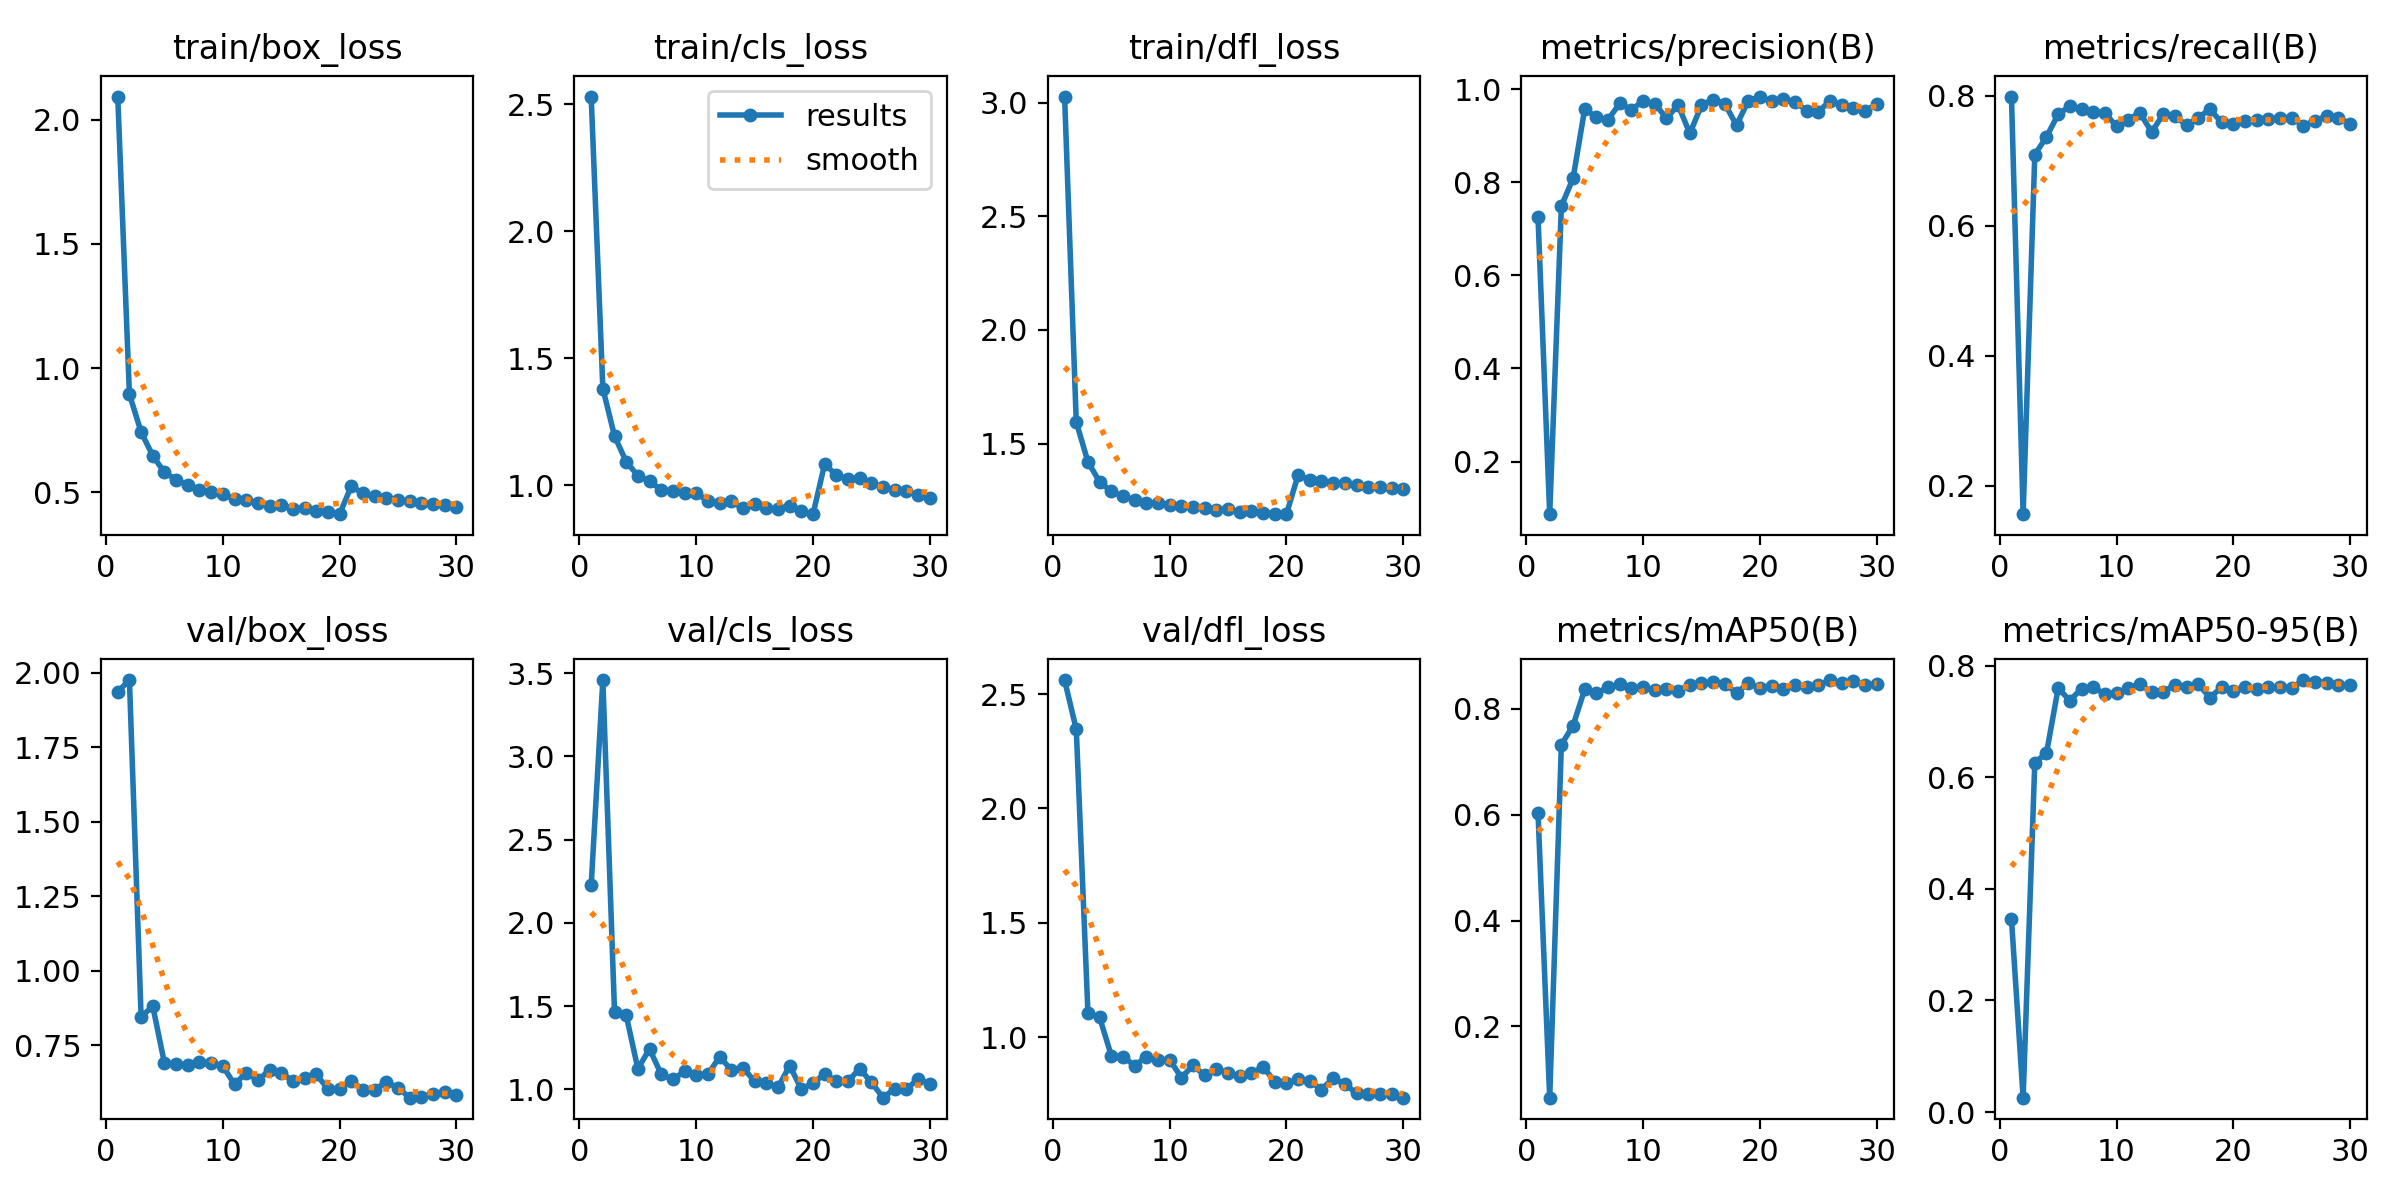

In [16]:
from IPython.display import Image, display

# Display composite visualization
display(Image(filename='/kaggle/working/runs/detect/yolov11_GLA3/results.png'))

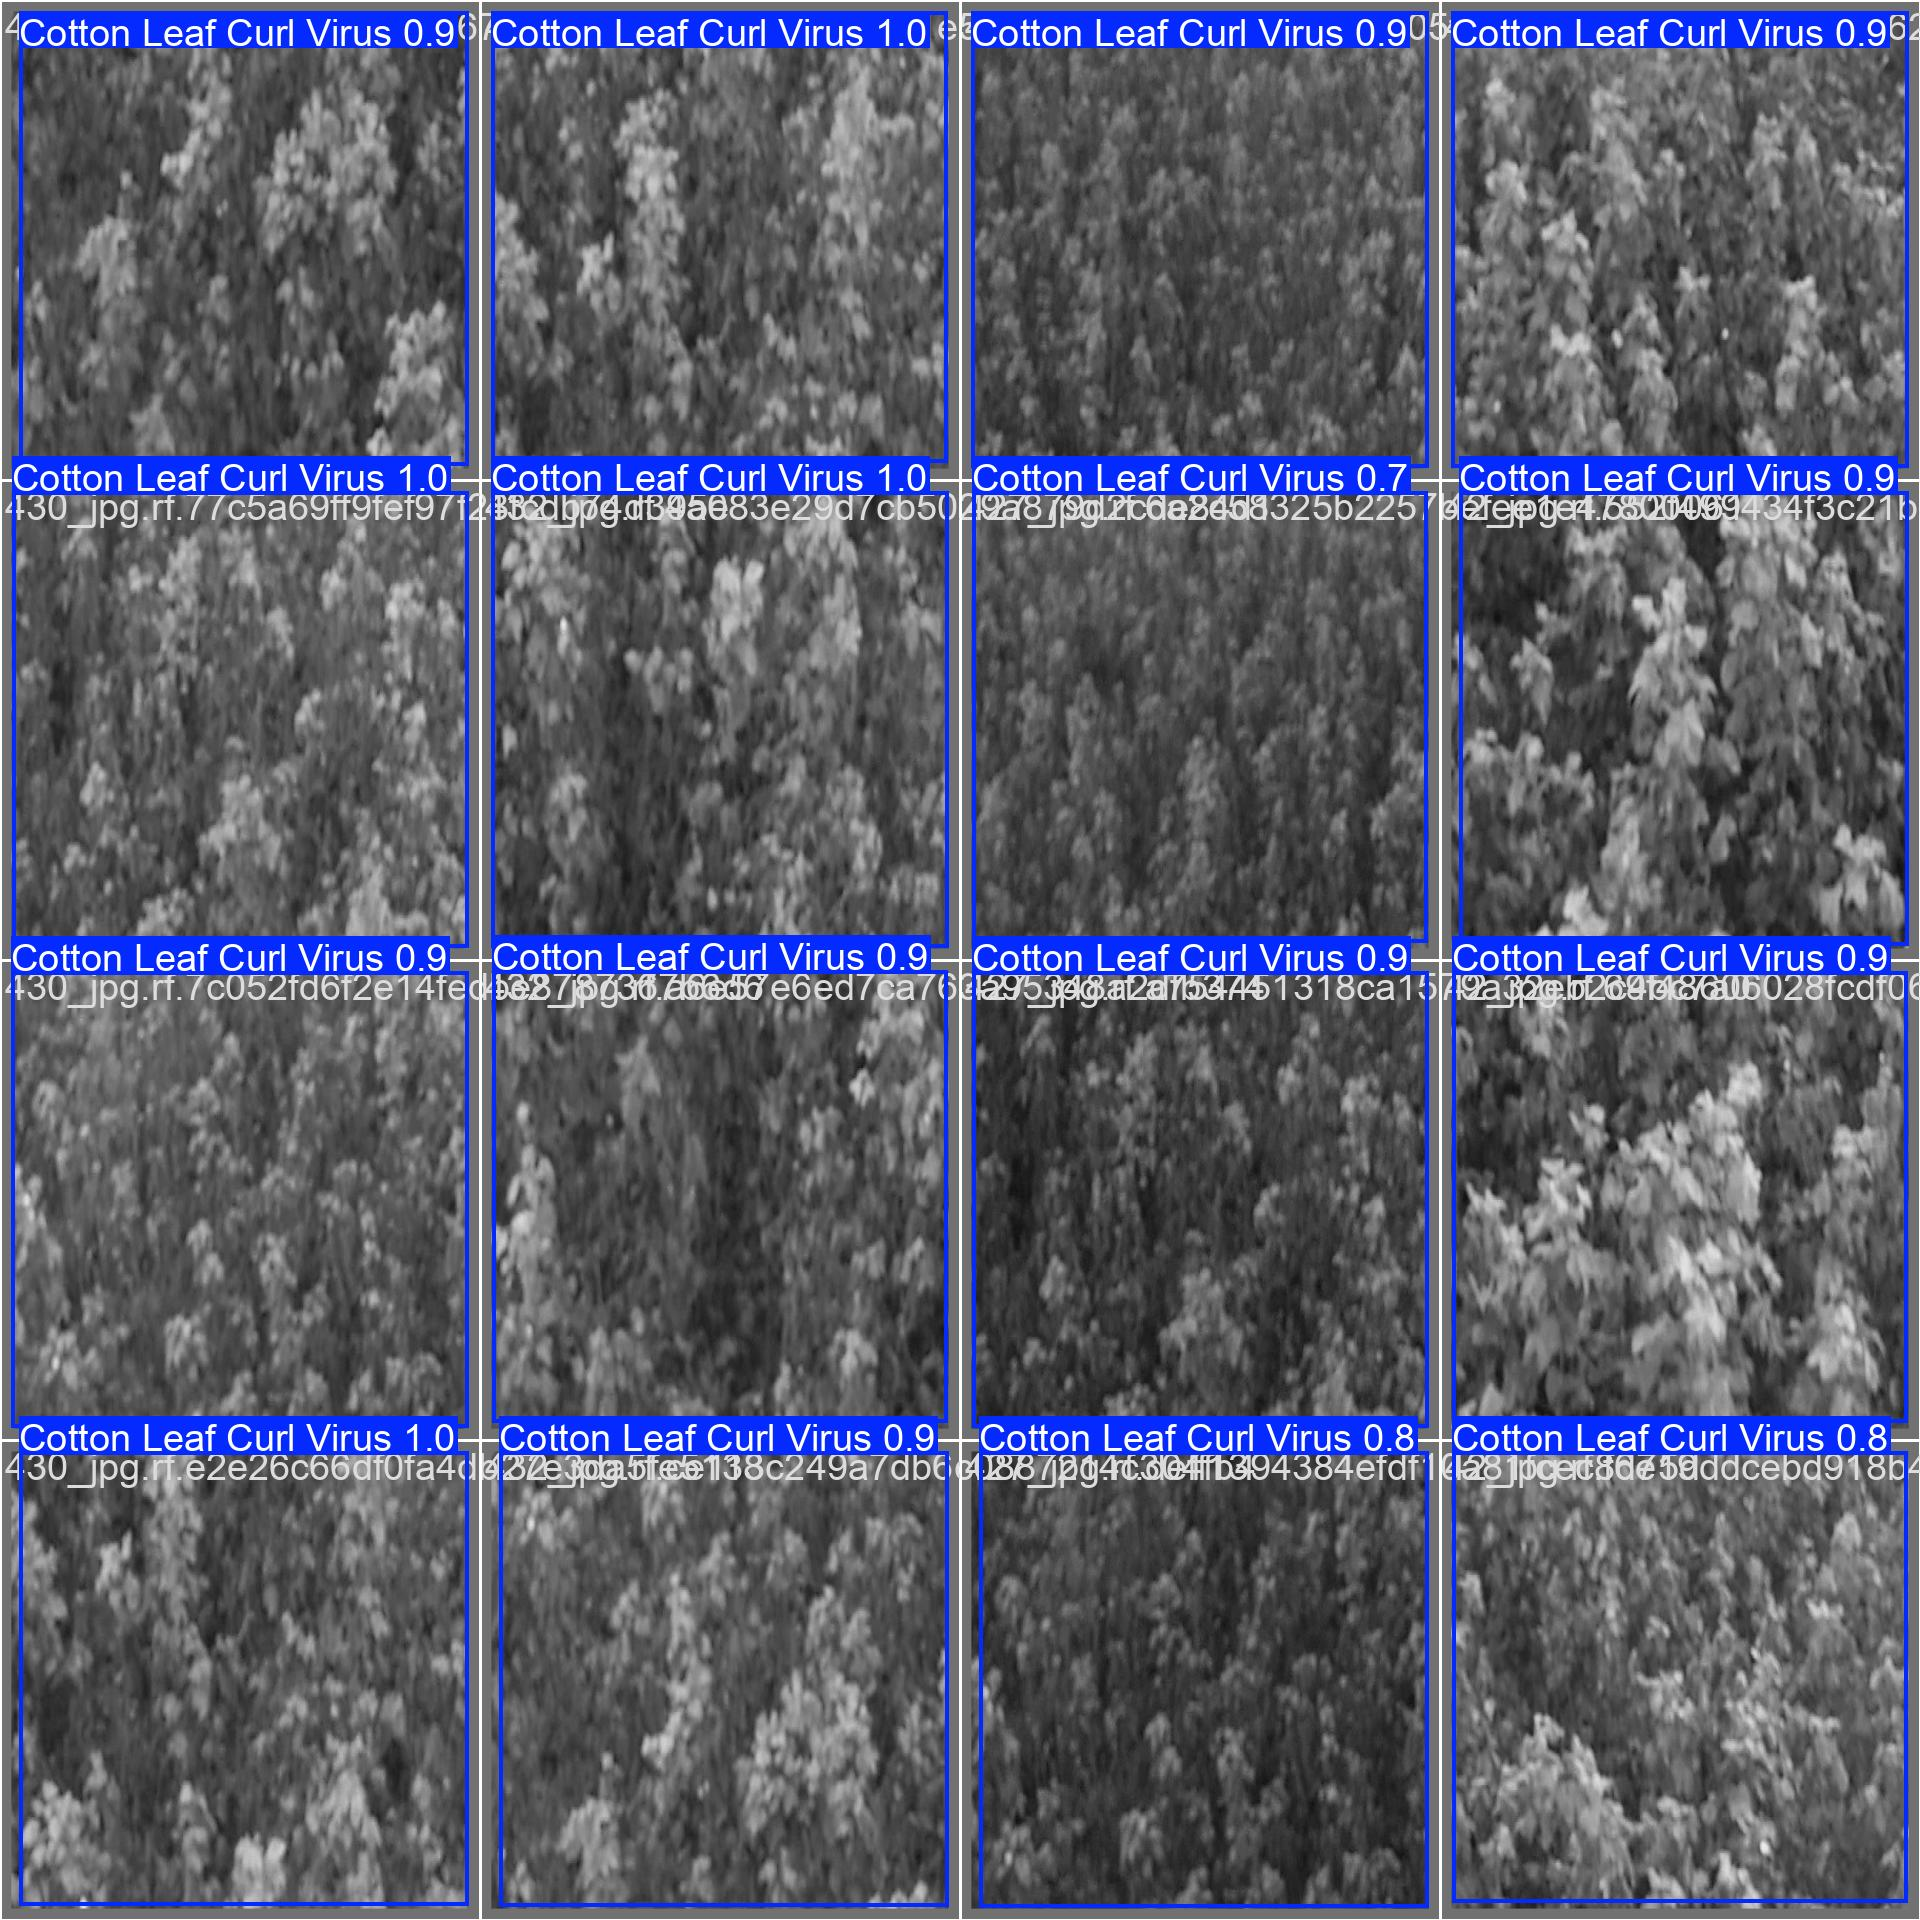

In [17]:
from IPython.display import Image, display

# Display composite visualization
display(Image(filename='/kaggle/working/runs/detect/yolov11_GLA3/val_batch2_pred.jpg'))